In [ ]:
предобработка и подготовка данных для логистической регрессии

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cirrhosis.csv")

display(df.head())

print(df.info())
X = df.drop(columns=["Status"])
y= df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
базовая логистическая регрессия 
сначала выполняется предобработка заполнение пропусков и масштабирование 

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

X_train_lr = X_train.drop(columns=["ID"])
X_test_lr = X_test.drop(columns=["ID"])

numeric_features = X_train_lr.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train_lr.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logreg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        multi_class="auto"
    ))
])

logreg_baseline.fit(X_train_lr, y_train)

y_pred = logreg_baseline.predict(X_test_lr)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Accuracy : 0.7619
Precision: 0.7169
Recall   : 0.7619
F1-score : 0.7369
              precision    recall  f1-score   support

           C       0.76      0.87      0.81        47
          CL       0.00      0.00      0.00         5
           D       0.77      0.72      0.74        32

    accuracy                           0.76        84
   macro avg       0.51      0.53      0.52        84
weighted avg       0.72      0.76      0.74        84

[[41  0  6]
 [ 4  0  1]
 [ 9  0 23]]


C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classificati

In [ ]:
опять проблема с CL классом, 
ворнинги видимо связаны как раз с дисбалансом этого класса 
 попробуем улучшить 

In [14]:
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", logreg)
])

grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_lr, y_train)

best_logreg = grid_search.best_estimator_
y_pred_best = best_logreg.predict(X_test_lr)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


              precision    recall  f1-score   support

           C       0.82      0.68      0.74        47
          CL       0.11      0.40      0.17         5
           D       0.74      0.62      0.68        32

    accuracy                           0.64        84
   macro avg       0.56      0.57      0.53        84
weighted avg       0.75      0.64      0.69        84

[[32  9  6]
 [ 2  2  1]
 [ 5  7 20]]


In [ ]:
 accuracy немного упало, зато класс CL перестал быть незаметным 
далее авторская реализация

In [15]:
class MyLogisticRegression:
    def __init__(self, lr=0.05, n_iters=4000):
        self.lr = lr
        self.n_iters = n_iters

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models_ = {}

        X = np.c_[np.ones(X.shape[0]), X]

        for cls in self.classes_:
            y_binary = (y == cls).astype(int)
            weights = np.zeros(X.shape[1])

            for _ in range(self.n_iters):
                linear = X @ weights
                y_hat = self._sigmoid(linear)
                gradient = X.T @ (y_hat - y_binary) / X.shape[0]
                weights -= self.lr * gradient

            self.models_[cls] = weights

        return self

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]

        scores = []
        for cls in self.classes_:
            w = self.models_[cls]
            scores.append(self._sigmoid(X @ w))

        scores = np.array(scores).T
        return self.classes_[np.argmax(scores, axis=1)]

X_train_proc = best_logreg.named_steps["preprocessor"].transform(X_train_lr)
X_test_proc = best_logreg.named_steps["preprocessor"].transform(X_test_lr)

X_train_proc = np.asarray(X_train_proc)
X_test_proc = np.asarray(X_test_proc)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

y_logreg = MyLogisticRegression(
    lr=0.05,
    n_iters=4000
)

my_logreg.fit(X_train_proc, y_train_enc)

y_pred_my_enc = my_logreg.predict(X_test_proc)
y_pred_my = le.inverse_transform(y_pred_my_enc)


print(classification_report(y_test, y_pred_my))

              precision    recall  f1-score   support

           C       0.75      0.85      0.80        47
          CL       0.00      0.00      0.00         5
           D       0.74      0.72      0.73        32

    accuracy                           0.75        84
   macro avg       0.50      0.52      0.51        84
weighted avg       0.70      0.75      0.73        84



C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
блок со сравнение результатов

,Model,Accuracy,F1_weighted,Recall_CL
0,Базовая,0.761905,0.736909,0.0
1,Улучшенная базовая,0.642857,0.685015,0.4
2,Авторская,0.750000,0.725775,0.0


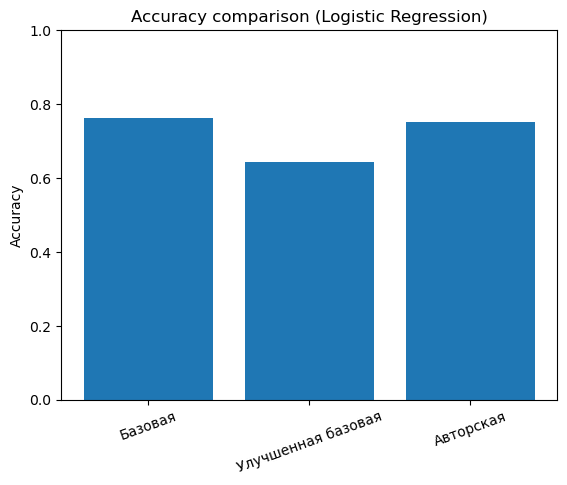

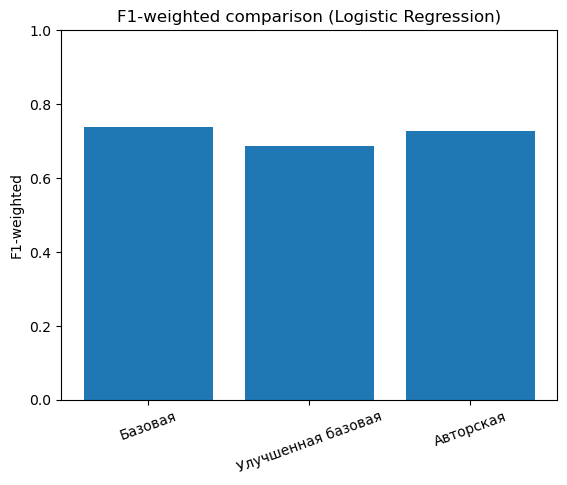

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_baseline = logreg_baseline.predict(X_test_lr)
y_pred_improved = best_logreg.predict(X_test_lr)
y_pred_custom = y_pred_my 

results = pd.DataFrame({
    "Model": [
        "Базовая",
        "Улучшенная базовая",
        "Авторская"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_improved),
        accuracy_score(y_test, y_pred_custom)
    ],
    "F1_weighted": [
        f1_score(y_test, y_pred_baseline, average="weighted"),
        f1_score(y_test, y_pred_improved, average="weighted"),
        f1_score(y_test, y_pred_custom, average="weighted")
    ],
    "Recall_CL": [
        recall_score(y_test, y_pred_baseline, labels=["CL"], average=None)[0],
        recall_score(y_test, y_pred_improved, labels=["CL"], average=None)[0],
        recall_score(y_test, y_pred_custom, labels=["CL"], average=None)[0]
    ]
})

display(results)

plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.title("Accuracy comparison (Logistic Regression)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(results["Model"], results["F1_weighted"])
plt.title("F1-weighted comparison (Logistic Regression)")
plt.ylabel("F1-weighted")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()



In [ ]:
Регрессия
Предобработка и разделение выборки

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_reg = pd.read_csv("mobile.csv").drop(columns=["Unnamed: 0"])

display(df_reg.head())
print(df_reg.info())

X = df_reg.drop(columns=["Price"])
y = df_reg["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,Brand me,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand me       836 non-null    object 
 1   Ratings        805 non-null    float64
 2   RAM            829 non-null    float64
 3   ROM            832 non-null    float64
 4   Mobile_Size    834 non-null    float64
 5   Primary_Cam    836 non-null    int64  
 6   Selfi_Cam      567 non-null    float64
 7   Battery_Power  836 non-null    int64  
 8   Price          836 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 58.9+ KB
None
X_train: (668, 8)
X_test : (168, 8)
y_train: (668,)
y_test : (168,)


In [ ]:
базовая линейная регрессия 

In [21]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

linreg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_baseline.fit(X_train,y_train)
y_pred = linreg_baseline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


MAE: 5358.64
MSE: 146669217.87
R2 : 0.9369


In [ ]:
хорошие ошибки, но попробуем еще улучшить 
попробуем взять посмотреть методы регуляризации Ridge и Lasso и сравним с рез-тами базовойверсии

In [24]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge best alpha:", ridge_grid.best_params_)
print(f"MAE: {mae_ridge:.2f}")
print(f"MSE: {mse_ridge:.2f}")
print(f"R2 : {r2_ridge:.4f}")

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=5000))
])

lasso_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 5, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso best alpha:", lasso_grid.best_params_)
print(f"MAE: {mae_lasso:.2f}")
print(f"MSE: {mse_lasso:.2f}")
print(f"R2 : {r2_lasso:.4f}")


Ridge best alpha: {'model__alpha': 0.01}
MAE: 4303.88
MSE: 104994377.97
R2 : 0.9548

Lasso best alpha: {'model__alpha': 1}
MAE: 2838.84
MSE: 86895799.82
R2 : 0.9626


In [ ]:
Обе дали незанчительное улучшение  

Теперь собственная линейная регрессия 


In [35]:
class MyLinearRegression:
    def __init__(self, lr=0.01, n_iters=4000):
        self.lr = lr
        self.n_iters = n_iters

    def fit(self, X, y):
        if sparse.issparse(X):
            X = X.toarray()

        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim == 1:
            X = X.reshape(-1, 1)
        X = np.c_[np.ones(X.shape[0]), X]

        self.weights = np.zeros(X.shape[1])

        for _ in range(self.n_iters):
            y_pred = X @ self.weights
            gradient = (X.T @ (y_pred - y)) / X.shape[0]
            self.weights -= self.lr * gradient

        return self

    def predict(self, X):
        if sparse.issparse(X):
            X = X.toarray()

        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights

X_train_proc = best_lasso.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_lasso.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()

X_train_proc = np.asarray(X_train_proc)
X_test_proc = np.asarray(X_test_proc)

y_train_np = np.asarray(y_train)
y_test_np = np.asarray(y_test)

my_linreg = MyLinearRegression(
    lr=0.1,
    n_iters=20000
)

my_linreg.fit(X_train_proc, y_train_np)

y_pred_my = my_linreg.predict(X_test_proc)

mae = mean_absolute_error(y_test_np, y_pred_my)
mse = mean_squared_error(y_test_np, y_pred_my)
r2 = r2_score(y_test_np, y_pred_my)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


MAE: 5066.12
MSE: 128234607.98
R2 : 0.9448


In [ ]:
R2 неплохая близкая к базовым 

In [ ]:
сравнеие результатов

,Model,MAE,MSE,R2
0,Linear Regression (baseline),5358.640355,1.466692e+08,0.936916
1,Ridge Regression,4303.880403,1.049944e+08,0.954841
2,Lasso Regression,2838.840063,8.689580e+07,0.962625
3,My Regression,5066.120689,1.282346e+08,0.944845


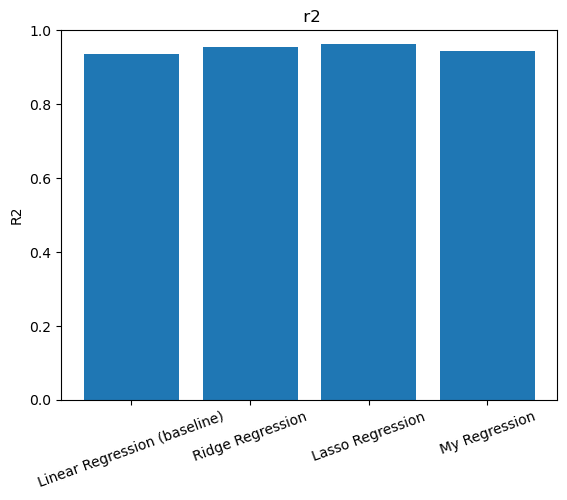

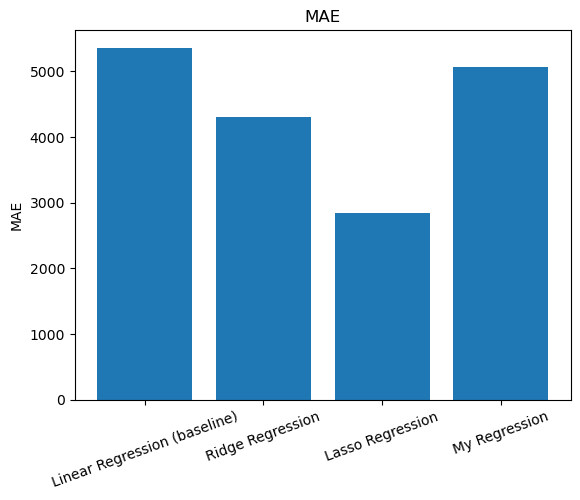

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_linreg  = linreg_baseline.predict(X_test)
y_pred_ridge   = best_ridge.predict(X_test)
y_pred_lasso   = best_lasso.predict(X_test)
y_pred_my_lin  = y_pred_my  

results_reg = pd.DataFrame({
    "Model": [
        "Linear Regression (baseline)",
        "Ridge Regression",
        "Lasso Regression",
        "My Regression"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linreg),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_my_lin)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_linreg),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_my_lin)
    ],
    "R2": [
        r2_score(y_test, y_pred_linreg),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_my_lin)
    ]
})

display(results_reg)

plt.figure()
plt.bar(results_reg["Model"], results_reg["R2"])
plt.title(" r2")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(results_reg["Model"], results_reg["MAE"])
plt.title("MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()
